# Classificadores Probabilísticos

**Francisco Aparecido Rodrigues**  
Universidade de São Paulo, São Carlos, Brasil  
<https://sites.icmc.usp.br/francisco>  

<hr>

Vamos estudar três abordagens para classificação baseadas no Teorema de Bayes:

1. **Classificador Bayesiano paramétrico** — assume que cada classe segue uma distribuição Normal multivariada (com matriz de covariância completa).
2. **Classificador Bayesiano não paramétrico** — estima a verossimilhança $p(x | C_k)$ usando Kernel Density Estimation (KDE), sem assumir uma família paramétrica.
3. **Naive Bayes** — um caso particular do classificador paramétrico em que se assume que os atributos são condicionalmente independentes dentro de cada classe (matriz de covariância diagonal).

Vamos inicialmente ler os dados:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(10)

#from google.colab import drive
#drive.mount('/content/drive/')
#data = pd.read_csv('/content/drive/My Drive/dados/Vehicle.csv', header=(0))
#data = pd.read_csv('/content/drive/My Drive/dados/iris.csv', header=(0))

#data = pd.read_csv('data/iris.csv', header=(0))
data = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\Vehicle.csv', header=(0))


print("Número de linhas e colunas:", data.shape)
data.head(10)

Número de linhas e colunas: (846, 19)


,Comp,Circ,D.Circ,Rad.Ra,Pr.Axis.Ra,Max.L.Ra,Scat.Ra,Elong,Pr.Axis.Rect,Max.L.Rect,Sc.Var.Maxis,Sc.Var.maxis,Ra.Gyr,Skew.Maxis,Skew.maxis,Kurt.maxis,Kurt.Maxis,Holl.Ra,Class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus
5,107,57,106,172,50,6,255,26,28,169,280,957,264,85,5,9,181,183,bus
6,97,43,73,173,65,6,153,42,19,143,176,361,172,66,13,1,200,204,bus
7,90,43,66,157,65,9,137,48,18,146,162,281,164,67,3,3,193,202,van
8,86,34,62,140,61,7,122,54,17,127,141,223,112,64,2,14,200,208,van
9,93,44,98,197,62,11,183,36,22,146,202,505,152,64,4,14,195,204,saab


Vamos construir as variáveis $X$ e $y$, sendo que o processo classificação se resume em estimar a função $f$ na relação $y = f(X) + \epsilon$, onde $\epsilon$ é o erro, que tem distribuição normal com média igual a zero e variância $\sigma^2$.

Convertemos os dados para o formato Numpy para facilitar a sua manipulação. Durante os cálculos, uma matriz NumPy é mais simples e eficiente do que alterar um `DataFrame` célula por célula. 

In [2]:
y = data.iloc[:,-1]
classes = np.array(pd.unique(y))
data = data.to_numpy()

nrow,ncol = data.shape
X = data[:,0:ncol-1]

Para treinar o classificador, precisamos definir o conjunto de teste e treinamento.

In [3]:
from sklearn.model_selection import train_test_split

p = 0.7 # fracao de elementos no conjunto de treinamento
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42)

A partir desse conjunto de dados, podemos realizar a classificação.

## Classificador Bayesiano

Em um problema de classificação, desejamos prever uma classe $C_k$ a partir de um vetor de atributos:
$$
\mathbf{x}=(x_1,x_2,\ldots,x_p).
$$
Exemplos:

- classificar um veículo;
- decidir se uma mensagem é spam;
- identificar uma doença a partir de medidas clínicas.

O teorema de Bayes é dado por
$$
P(C_k\mid \mathbf{x})=
\frac{p(\mathbf{x}\mid C_k)P(C_k)}
{p(\mathbf{x})}.
$$
Os termos possuem as seguintes interpretações:

- $P(C_k)$: probabilidade **a priori** da classe;
- $p(\mathbf{x}\mid C_k)$: **verossimilhança** dos atributos dentro da classe;
- $P(C_k\mid \mathbf{x})$: probabilidade **a posteriori**;
- $p(\mathbf{x})$: evidência.

Para classificar uma observação, escolhemos a classe com maior probabilidade a posteriori:
$$
\widehat{C}(\mathbf{x})
=
\arg\max_k P(C_k\mid \mathbf{x}).
$$
Como $p(\mathbf{x})$ é igual para todas as classes, podemos comparar apenas
$$
p(\mathbf{x}\mid C_k)P(C_k).
$$

No modelo paramétrico, assumimos que os atributos de cada classe seguem uma distribuição Normal multivariada:

$$
p(\mathbf{x}\mid C_k)
=
\mathcal{N}(\mathbf{x};\boldsymbol{\mu}_k,\boldsymbol{\Sigma}_k),
$$

onde:
- $\boldsymbol{\mu}_k$ é o vetor de médias da classe;
- $\boldsymbol{\Sigma}_k$ é a matriz de covariância da classe.

Esses parâmetros são estimados usando apenas as observações do conjunto de treinamento.

Na prática, quando o número de atributos $p$ é grande, o produto $p(\mathbf{x}\mid C_k)P(C_k)$ pode ficar muito próximo de zero (underflow numérico). Uma solução comum é trabalhar com o logaritmo dessas quantidades, já que o argmax é preservado: $\arg\max_k [\log p(\mathbf{x}\mid C_k) + \log P(C_k)]$.

Em um problema de classificação, desejamos prever uma classe \(C_k\) a partir de um vetor de atributos:
$$
\mathbf{x}=(x_1,x_2,\ldots,x_p).
$$
Exemplos:


- classificar um veículo;
- decidir se uma mensagem é spam;
- identificar uma doença a partir de medidas clínicas.
  
O teorema de Bayes é dado por
$$
P(C_k\mid \mathbf{x})=
\frac{p(\mathbf{x}\mid C_k)P(C_k)}
{p(\mathbf{x})}.
$$
Os termos possuem as seguintes interpretações:

- $P(C_k)$: probabilidade **a priori** da classe;
- $p(\mathbf{x}\mid C_k)$: **verossimilhança** dos atributos dentro da classe;
- $P(C_k\mid \mathbf{x})$: probabilidade **a posteriori**;
- $p(\mathbf{x})$: evidência.

Para classificar uma observação, escolhemos a classe com maior probabilidade a posteriori:
$$
\widehat{C}(\mathbf{x})
=
\arg\max_k P(C_k\mid \mathbf{x}).
$$
Como $p(\mathbf{x})$ é igual para todas as classes, podemos comparar apenas
$$
p(\mathbf{x}\mid C_k)P(C_k).
$$

No modelo paramétrico, assumimos que os atributos de cada classe seguem uma distribuição Normal multivariada:

$$
p(\mathbf{x}\mid C_k)
=
\mathcal{N}(\mathbf{x};\boldsymbol{\mu}_k,\boldsymbol{\Sigma}_k),
$$

onde:
- $\boldsymbol{\mu}_k$ é o vetor de médias da classe;
- $\boldsymbol{\Sigma}_k$ é a matriz de covariância da classe.

Esses parâmetros são estimados usando apenas as observações do conjunto de treinamento.

Vamos considerar o caso paramétrico, assumindo que cada variável está distribuída de acordo com uma distribuição Normal. Outras distribuições também podem ser utilizadas.

Já selecionamos os conjuntos de treinamento e teste anteriormente. No conjunto de treinamento, vamos calcular a média e desvio padrão de cada atributo para cada classe. A seguir, realizamos a classificação, dos dados usando a teoria da decisão Bayesiana, isto é: $X \in C_i$ se, e somente se, $P(C_i|X) = \max P(C_j|X)$ para todo $j$.

In [4]:
from scipy.stats import multivariate_normal

# Cria uma matriz para armazenar, para cada exemplo do conjunto de teste, a probabilidade associada a cada classe.
# Número de linhas  = número de exemplos em X_test
# Número de colunas = número de classes
P = pd.DataFrame(
    data=np.zeros((X_test.shape[0], len(classes))),
    columns=classes
)
# Vetor que armazenará a probabilidade a priori de cada classe.
# Exemplo: Pc[i] = proporção de exemplos da classe i no conjunto de treinamento.
Pc = np.zeros(len(classes))

# Percorre todas as classes existentes no problema.
for i in np.arange(0, len(classes)):
    # Localiza os índices dos exemplos de treinamento
    # que pertencem à classe atual.
    elements = np.array(
        np.where(y_train == classes[i])
    )
    # Calcula a probabilidade a priori da classe atual:
    # P(classe i) = número de exemplos da classe i / número total de exemplos de treinamento
    Pc[i] = elements.shape[1] / len(y_train)

    # Seleciona, em X_train, somente os exemplos que pertencem à classe atual.
    # O astype(float) garante que os dados sejam numéricos.
    Z = X_train[elements, :][0].astype(float)

    # Calcula o vetor médio dos atributos para a classe atual. Cada posição de m corresponde à média de um atributo.
    m = np.mean(Z,axis=0)

    # Calcula a matriz de covariância dos atributos para a classe atual.
    # A transposição é necessária porque np.cov espera, por padrão, que cada linha represente uma variável.
    cv = np.cov(np.transpose(Z))

    # Percorre todos os exemplos do conjunto de teste.
    for j in np.arange(0, X_test.shape[0]):
        # Seleciona o exemplo j do conjunto de teste.
        x = X_test[j, :]
        # Calcula a densidade de probabilidade do exemplo x segundo uma distribuição 
        # normal multivariada com média m e matriz de covariância cv.
        # Isto representa a verossimilhança: P(x | classe i)
        pj = multivariate_normal.pdf(x,mean=m,cov=cv,allow_singular=True)

        # Multiplica a verossimilhança pela probabilidade a priori: P(x | classe i) * P(classe i)
        # Pelo teorema de Bayes, esse valor é proporcional à probabilidade posterior: P(classe i | x)
        # Não é necessário dividir por P(x), pois esse termo é igual para todas as classes.
        P.loc[j, classes[i]] = pj * Pc[i]

In [5]:
print(P)

              van          saab           bus          opel
0    3.151847e-31  9.858817e-33  3.543175e-22  2.008144e-31
1    6.312434e-22  8.955506e-55  3.281194e-42  8.854235e-50
2    9.549453e-27  5.676222e-27  2.992373e-21  5.149165e-27
3    9.547932e-24  1.721556e-22  8.561567e-31  1.066572e-23
4    1.378438e-24  1.437899e-23  1.577016e-19  2.212885e-22
..            ...           ...           ...           ...
249  0.000000e+00  3.956652e-48  1.151983e-24  4.088737e-38
250  9.983964e-41  1.042205e-27  1.593905e-21  1.251171e-26
251  3.347217e-26  9.737831e-25  9.084512e-27  2.271166e-23
252  9.126644e-31  7.769182e-21  8.030936e-30  4.552604e-21
253  2.841329e-20  4.741875e-45  1.377657e-43  4.032846e-40

[254 rows x 4 columns]


Classifica de acordo com a classe mais provável:

In [6]:
# Lista que armazenará as classes previstas para cada exemplo.
y_pred = []
# Percorre todas as observações do conjunto de teste.
for i in range(X_test.shape[0]):
    # Seleciona a linha i da matriz de probabilidades.
    # Cada coluna corresponde à probabilidade de uma classe.
    # Exemplo:
    # Classe A   Classe B   Classe C
    #   0.15       0.72       0.13
    # O maior valor indica a classe prevista.
    c = np.argmax(np.array(P.iloc[i]))
    # Converte o índice da maior probabilidade para o nome da classe correspondente.
    y_pred.append(classes[c])

# Converte a lista em um vetor NumPy.
y_pred = np.array(y_pred)

# Garante que y_test também seja um vetor NumPy.
y_test = np.array(y_test)

# Mostra as classes previstas.
print(y_pred)

['bus' 'van' 'bus' 'saab' 'bus' 'van' 'van' 'saab' 'bus' 'saab' 'saab'
 'bus' 'van' 'opel' 'opel' 'van' 'saab' 'bus' 'saab' 'opel' 'van' 'van'
 'opel' 'opel' 'opel' 'saab' 'opel' 'van' 'van' 'van' 'opel' 'van' 'bus'
 'van' 'van' 'bus' 'bus' 'saab' 'bus' 'opel' 'van' 'bus' 'opel' 'van'
 'saab' 'saab' 'bus' 'van' 'bus' 'van' 'bus' 'bus' 'van' 'saab' 'bus'
 'opel' 'saab' 'opel' 'saab' 'saab' 'bus' 'van' 'saab' 'bus' 'bus' 'bus'
 'saab' 'saab' 'opel' 'opel' 'saab' 'bus' 'saab' 'bus' 'van' 'van' 'saab'
 'opel' 'saab' 'van' 'bus' 'van' 'saab' 'saab' 'opel' 'saab' 'van' 'bus'
 'van' 'saab' 'saab' 'opel' 'bus' 'bus' 'opel' 'bus' 'van' 'van' 'bus'
 'opel' 'saab' 'saab' 'opel' 'van' 'bus' 'bus' 'saab' 'van' 'saab' 'opel'
 'van' 'bus' 'van' 'bus' 'bus' 'van' 'bus' 'opel' 'bus' 'saab' 'bus'
 'opel' 'saab' 'van' 'bus' 'saab' 'bus' 'van' 'bus' 'saab' 'bus' 'van'
 'bus' 'saab' 'bus' 'bus' 'bus' 'saab' 'opel' 'bus' 'van' 'saab' 'bus'
 'bus' 'van' 'opel' 'saab' 'opel' 'van' 'saab' 'opel' 'bus' 'bus' 's

In [7]:
from sklearn.metrics import accuracy_score

score = accuracy_score(y_pred, y_test)
print('Accuracy:', score)

Accuracy: 0.8937007874015748


## Caso não paramétrico

Para o caso unidimensional, seja $(X_1,X_2, \ldots, X_n)$ uma amostra aleatória unidimensional identicamente distribuída de acordo com alguma função de distribuição $f$ não conhecida. Para estimarmos o formato de $f$, usamos um estimador (kernel density estimator):
\begin{equation}
\widehat{f}_{h}(x)={\frac {1}{n}}\sum _{i=1}^{n}K_{h}(x-x_{i})={\frac {1}{nh}}\sum _{i=1}^{n}K{\Big (}{\frac {x-x_{i}}{h}}{\Big )},
\end{equation}
onde $K$ é a função kernel.
A estimação depende do parâmetro $h$, que é um parâmetro livre e controla a abertura da função.

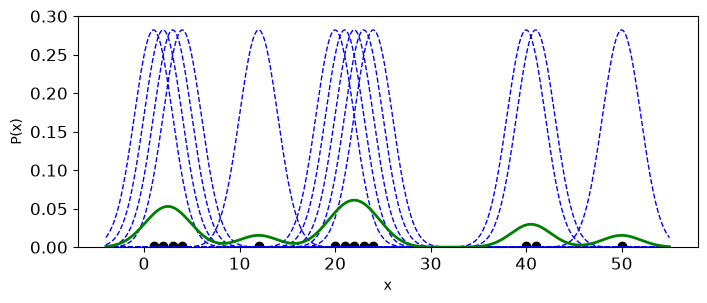

In [8]:
import numpy as np
import matplotlib.pyplot as plt

N = 20
# gera os dados
X = np.array([1, 2, 3, 4, 12, 20,21,22,23,24,40,41, 50])
X = X.reshape((len(X), 1))
# mostra os dados
plt.figure(figsize=(8,3))
plt.plot(X[:, 0], 0.001*np.ones(X.shape[0]), 'ok')

# valores x para serem usados nas densidades
X_plot = np.linspace(np.min(X)-5, np.max(X)+5, 1000)[:, np.newaxis]

h=2
fhat = 0 # estimacao obtida
for x in X:
    # distribuição normal centrada em x
    f = (1/np.sqrt(2*np.pi*h))*np.exp(-((X_plot - x)**2)/(2*h**2))
    fhat = fhat + f # acumula as distribuições
    plt.plot(X_plot,f, '--', color = 'blue', linewidth=1)

# mostra a distribuição estimada
plt.plot(X_plot,fhat/(len(X)*np.sqrt(h)), color = 'green', linewidth=2)
plt.xlabel('x', fontsize = 10)
plt.ylabel('P(x)', fontsize = 10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim((0, 0.3))
plt.show(True)

Esse resultado pode ser obtido usando-se a função KernelDensity scikit-learn.

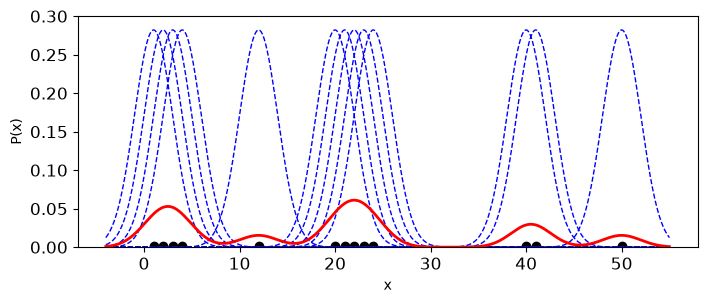

In [9]:
import numpy as np
from matplotlib.pyplot import cm
from sklearn.neighbors import KernelDensity

color=['red', 'blue', 'magenta', 'gray', 'green']

N = 20
X = np.array([1, 2, 3, 4, 12, 20,21,22,23,24,40,41, 50])
X = X.reshape((len(X), 1))

plt.figure(figsize=(8,3))
plt.plot(X[:, 0], 0.001*np.ones(X.shape[0]), 'ok')

X_plot = np.linspace(np.min(X)-5, np.max(X)+5, 1000)[:, np.newaxis]

h=2
fhat = 0
for x in X:
    f = (1/np.sqrt(2*np.pi*h))*np.exp(-((X_plot - x)**2)/(2*h**2))
    plt.plot(X_plot,f, '--', color = 'blue', linewidth=1)

kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(X)
log_dens = np.exp(kde.score_samples(X_plot)) # score_samples() returns the log density.
plt.plot(X_plot,log_dens, color = 'red', linewidth=2, label = 'h='+str(h))
plt.xlabel('x', fontsize = 10)
plt.ylabel('P(x)', fontsize = 10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim((0, 0.3))

plt.show(True)

Notem que o formato da estimação depende do parâmetro livre $h$.

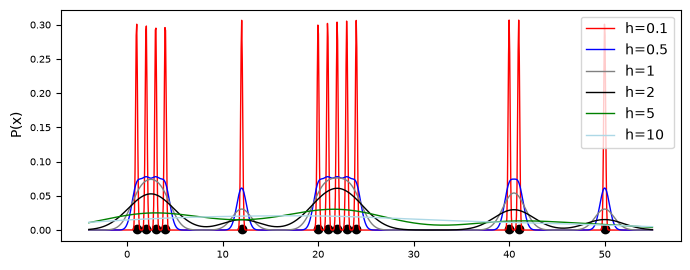

In [10]:
import numpy as np
from matplotlib.pyplot import cm

color=['red', 'blue', 'gray', 'black', 'green', 'lightblue']

N = 20
X = np.array([1, 2, 3, 4, 12, 20,21,22,23,24,40,41, 50])
X = X.reshape((len(X), 1))

X_plot = np.linspace(np.min(X)-5, np.max(X)+5, 1000)[:, np.newaxis]

plt.figure(figsize=(8,3))
plt.plot(X[:, 0], 0.001*np.ones(X.shape[0]), 'ok')
c = 0
vh = [0.1, 0.5, 1, 2, 5, 10]
for h in vh:
    kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(X)
    log_dens = np.exp(kde.score_samples(X_plot)) # score_samples() returns the log density.
    plt.plot(X_plot,log_dens, color = color[c], linewidth=1, label = 'h='+str(h))
    c = c + 1
plt.ylabel('P(x)', fontsize = 10)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
#plt.ylim((0, 0.2))
plt.legend(fontsize = 10)
plt.show(True)

Usando o método kernel density estimation, podemos realizar a classificação: em vez de assumir uma Normal multivariada por classe, estimamos $p(x | C_k)$ diretamente a partir dos dados.

**Padronização dos atributos:** o `KernelDensity` do scikit-learn usa uma única largura de banda h para todos os atributos simultaneamente. Se os atributos tiverem escalas muito diferentes (no Vehicle, por exemplo, `Sc.Var.maxis` chega a centenas enquanto `Skew.maxis` fica na casa das dezenas), o mesmo h terá efeitos completamente diferentes em cada dimensão — geralmente favorecendo os atributos de maior variância. Por isso, aplicamos um `StandardScaler` (ajustado apenas no treino) antes de estimar o KDE.

In [12]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity
from sklearn.metrics import accuracy_score


#drive.mount('/content/drive/')
#data = pd.read_csv('/content/drive/My Drive/dados/Vehicle.csv', header=(0))

data = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\Vehicle.csv', header=(0))

classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)

# Converte para matriz e vetor do numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

# Seleciona os conjuntos de treinamento e teste
p = 0.7 # fraction of elements in the training set
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Matriz que armazena as probabilidades para cada classe
P = pd.DataFrame(data=np.zeros((x_test.shape[0], len(classes))), columns = classes)
Pc = np.zeros(len(classes)) # Armaze a fracao de elementos em cada classe
h = 4
for i in np.arange(0, len(classes)): # Para cada classe
    elements = tuple(np.where(y_train == classes[i])) # elmentos na classe i
    Pc[i] = len(elements)/len(y_train) # Probabilidade pertencer a classe i
    Z = x_train[elements,:][0].astype(float) # Elementos no conjunto de treinamento
    kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(Z)
    for j in np.arange(0,x_test.shape[0]): # para cada observacao no conjunto de teste
        x = x_test[j,:]
        x = x.reshape((1,len(x)))
        # calcula a probabilidade pertencer a cada classe
        pj = np.exp(kde.score_samples(x))
        P.loc[j,classes[i]] = pj*Pc[i]

y_pred = [] # Vetor com as classes preditas
for i in np.arange(0, x_test.shape[0]):
    c = np.argmax(np.array(P.iloc[[i]]))
    y_pred.append(classes[c])
y_pred = np.array(y_pred, dtype=str)
# calcula a acuracia
score = accuracy_score(y_pred, y_test)
print('Acuracia:', score)

Acuracia: 0.6496062992125984


Notem que a acurácia depende do parâmetro $h$, conforme verficamos abaixo.

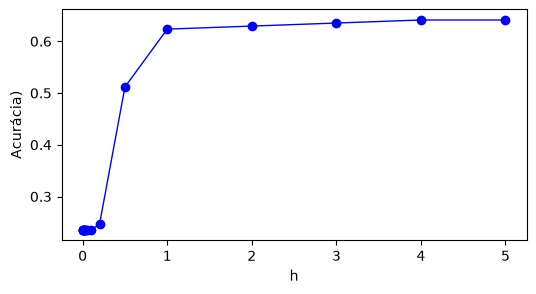

In [13]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import multivariate_normal
from sklearn.metrics import accuracy_score

# se for ler do Google Colab:
#drive.mount('/content/drive/')
#data = pd.read_csv('/content/drive/My Drive/dados/Vehicle.csv', header=(0))

data = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\Vehicle.csv', header=(0))

classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)

# Converte para matriz e vetor do numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

# Seleciona os conjuntos de treinamento e teste
p = 0.8 # fraction of elements in the test set
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42)

####  Realiza a classificacao ####
vacc = []
vh = [0.001,0.002,0.003,0.005,0.01,0.02,0.03,0.04, 0.05, 0.1, 0.2, 0.5, 1, 2,3,4, 5]
plt.figure(figsize=(6,3))
for h in vh:
    # Matriz que armazena as probabilidades para cada classe
    P = pd.DataFrame(data=np.zeros((x_train.shape[0], len(classes))), columns = classes)
    Pc = np.zeros(len(classes)) # Armaze a fracao de elementos em cada classe
    for i in np.arange(0, len(classes)): # Para cada classe
        elements = tuple(np.where(y_train == classes[i])) # elmentos na classe i
        Pc[i] = len(elements)/len(y_train) # Probabilidade pertencer a classe i
        Z = x_train[elements,:][0].astype(float) # Elementos no conjunto de treinamento
        kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(Z)
        for j in np.arange(0,x_test.shape[0]): # para cada observacao no conjunto de teste
            x = x_test[j,:]
            x = x.reshape((1,len(x)))
            # calcula a probabilidade pertencer a cada classe
            pj = np.exp(kde.score_samples(x))
            P.loc[j,classes[i]] = pj*Pc[i]

    y_pred = [] # Vetor com as classes preditas
    for i in np.arange(0, x_test.shape[0]):
        c = np.argmax(np.array(P.iloc[[i]]))
        y_pred.append(classes[c])
    y_pred = np.array(y_pred, dtype=str)
    # calcula a acuracia
    score = accuracy_score(y_pred, y_test)
    vacc.append(score)
    #print('Acuracia:', score)

plt.plot(vh,vacc, 'o-', color = 'blue', linewidth=1)
plt.xlabel('h', fontsize = 10)
plt.ylabel('Acurácia)', fontsize = 10)
plt.show(True)

## Naive Bayes

O classificador Naive Bayes é um caso particular do classificador Bayesiano paramétrico que acabamos de implementar: em vez de estimar a matriz de covariância completa $\boldsymbol{\Sigma}_k$ de cada classe, assume-se que os atributos são condicionalmente independentes dado a classe, isto é,
$$
p(\mathbf{x}\mid C_k) = \prod_{j=1}^{p} p(x_j \mid C_k),
$$
o que equivale a usar uma matriz de covariância diagonal. Essa suposição ("naive" = ingênua) raramente é exatamente verdadeira, mas o classificador costuma funcionar bem na prática, é muito rápido de treinar e precisa estimar muito menos parâmetros — o que é especialmente útil quando há poucos exemplos por classe em relação ao número de atributos.

No `GaussianNB` do scikit-learn, assumimos ainda que cada atributo, dentro de cada classe, segue uma distribuição Normal univariada.

Vamos ler os dados novamente para evitar que alguma transformação anterior afete os resultados.

In [14]:
import random
random.seed(42) # define the seed (important to reproduce the results)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#from google.colab import drive
#drive.mount('/content/drive/')
#data = pd.read_csv('/content/drive/My Drive/dados/iris.csv', header=(0))

#data = pd.read_csv('data/iris.csv', header=(0))
data = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\Vehicle.csv', header=(0))

data = data.dropna(axis='rows') #remove NaN
# armazena os nomes das classes
classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)

print("Número de linhas e colunas na matriz de atributos:", data.shape)
attributes = list(data.columns)
data.head(10)

Número de linhas e colunas na matriz de atributos: (846, 19)


,Comp,Circ,D.Circ,Rad.Ra,Pr.Axis.Ra,Max.L.Ra,Scat.Ra,Elong,Pr.Axis.Rect,Max.L.Rect,Sc.Var.Maxis,Sc.Var.maxis,Ra.Gyr,Skew.Maxis,Skew.maxis,Kurt.maxis,Kurt.Maxis,Holl.Ra,Class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus
5,107,57,106,172,50,6,255,26,28,169,280,957,264,85,5,9,181,183,bus
6,97,43,73,173,65,6,153,42,19,143,176,361,172,66,13,1,200,204,bus
7,90,43,66,157,65,9,137,48,18,146,162,281,164,67,3,3,193,202,van
8,86,34,62,140,61,7,122,54,17,127,141,223,112,64,2,14,200,208,van
9,93,44,98,197,62,11,183,36,22,146,202,505,152,64,4,14,195,204,saab


In [15]:
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

Selecionando os conjuntos de treinamento e teste.

In [16]:
from sklearn.model_selection import train_test_split

p = 0.3 # fraction of elements in the test set
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = p, random_state = 42)

Podemos realizar a classificação.

In [17]:
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

model = GaussianNB()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print('Accuracy: ', model.score(x_test, y_test))

Accuracy:  0.4566929133858268


# Exercícios de fixação

1 - Repita a classificação da base Vehicle.csv usando outra fração de treino/teste (por exemplo, p = 0.5) e discuta como as acurácias mudam. Use o Naive Bayes.

In [ ]:
import random
random.seed(42) # define the seed (important to reproduce the results)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

#from google.colab import drive
#drive.mount('/content/drive/')
#data = pd.read_csv('/content/drive/My Drive/dados/iris.csv', header=(0))

#data = pd.read_csv('data/iris.csv', header=(0))
data = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\Vehicle.csv', header=(0))

data = data.dropna(axis='rows') #remove NaN
# armazena os nomes das classes
classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)

print("Número de linhas e colunas na matriz de atributos:", data.shape)
attributes = list(data.columns)
# data.head(10)

# Converte para matriz e vetor do numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

# Separação de treino e teste
p = 0.5 # fraction of elements in the test set
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = p, random_state = 42)

# modelo
model = GaussianNB()
model.fit(x_train, y_train)

# predição
y_pred = model.predict(x_test)
print('Accuracy: ', model.score(x_test, y_test))

Número de linhas e colunas na matriz de atributos: (846, 19)
Accuracy:  0.4562647754137116


A acurácia muda muito pouco porque o Naive Bayes só precisa estimar uma média e um desvio-padrão por atributo, por classe. 

O conjunto de treino "antes" (70% da base, 593 exemplos) já era mais que suficiente para estimar bem esses parâmetros, já que são poucos valores por classe. Ao reduzir o treino para 50% (423 exemplos), ainda sobra dado de sobra para essas estimativas simples, então a queda de desempenho é mínima.

Mais dados de treino trariam pouco ganho de qualquer forma, porque o gargalo de desempenho do modelo não é a quantidade de dados, e sim a suposição de independência entre os atributos, que é violada nessa base (atributos como Scat.Ra e Sc.Var.maxis têm correlação de 0.996).


2 - Substitua a acurácia por outra métrica (por exemplo, F1-score, AUC) para escolher o valor de h na etapa de validação. O valor escolhido muda?

Melhor h por Accuracy : 4 -> accuracy = 0.6496
Melhor h por F1-macro : 4 -> F1-macro = 0.6385


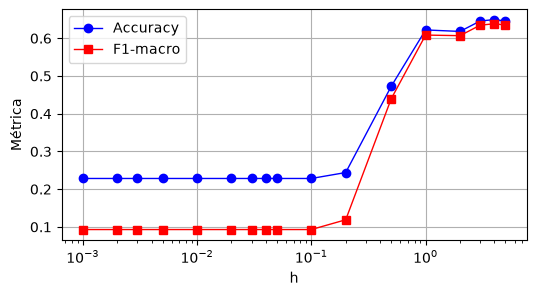

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity
from sklearn.metrics import accuracy_score, f1_score


#drive.mount('/content/drive/')
#data = pd.read_csv('/content/drive/My Drive/dados/Vehicle.csv', header=(0))

data = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\Vehicle.csv', header=(0))

classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)

# Converte para matriz e vetor do numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

# Seleciona os conjuntos de treinamento e teste
p = 0.7 # fraction of elements in the training set
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Realiza a classificacao para cada h, guardando accuracy e F1-macro ####
vacc = []
vf1 = []
vh = [0.001,0.002,0.003,0.005,0.01,0.02,0.03,0.04, 0.05, 0.1, 0.2, 0.5, 1, 2, 3, 4, 5]

for h in vh:
    P = pd.DataFrame(data=np.zeros((x_test.shape[0], len(classes))), columns = classes)
    Pc = np.zeros(len(classes))
    for i in np.arange(0, len(classes)):
        elements = np.where(y_train == classes[i])[0]
        Pc[i] = len(elements) / len(y_train)
        Z = x_train[elements, :].astype(float)
        kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(Z)
        for j in np.arange(0, x_test.shape[0]):
            x = x_test[j, :].reshape((1, -1))
            pj = np.exp(kde.score_samples(x))
            P.loc[j, classes[i]] = pj * Pc[i]

    y_pred = np.array([classes[np.argmax(P.iloc[j].values)] for j in range(x_test.shape[0])])

    vacc.append(accuracy_score(y_test, y_pred))
    # F1-macro: media do F1 calculado independentemente em cada classe,
    # tratando todas as classes com o mesmo peso (bom para comparar com a accuracy
    # em problemas multiclasse, principalmente se houver desbalanceamento)
    vf1.append(f1_score(y_test, y_pred, average='macro'))

best_h_acc = vh[int(np.argmax(vacc))]
best_h_f1 = vh[int(np.argmax(vf1))]
print('Melhor h por Accuracy :', best_h_acc, '-> accuracy =', round(max(vacc), 4))
print('Melhor h por F1-macro :', best_h_f1, '-> F1-macro =', round(max(vf1), 4))

plt.figure(figsize=(6,3))
plt.plot(vh, vacc, 'o-', color='blue', linewidth=1, label='Accuracy')
plt.plot(vh, vf1, 's-', color='red', linewidth=1, label='F1-macro')
plt.xscale('log')
plt.xlabel('h', fontsize=10)
plt.ylabel('Métrica', fontsize=10)
plt.legend()
plt.grid()
plt.show(True)